# Publication figures — finetune integration (ablations)

Loads finetune trial results, groups by **trial name** (all parameters except seed), and plots mean with shaded error band (SEM, STD, or 95% CI) across seeds.

**Ablation figures** — one figure per **task** (`TASKS_TO_PLOT`: Passive, Active, Pooled):
- **Subplots** = neural conditions (Baseline-PER, Prioritization, Reward Augmentation, …)
- **Lines** = ablation level at fixed baseline values for the other hyperparameters:
  - **Finetune threshold** (`ft`) at noise=0, β=1
  - **Model noise** at β=1; `ft` set via `NOISE_BETA_ABLATION_FT` / `plot_ablation_for_each_task(..., ft=...)`
  - **Neural β** at noise=0; same `ft` control

**Summary** — optional figure with best curve per task × condition, selected by:
- **Reward** — highest returns (blend of peak and terminal performance)
- **Speed** — high reward reached in fewer evaluation checkpoints


**Colors:** edit `LINE_COLORS` and `CONDITION_COLORS` in the config cell (hex values).
**Layout:** `FIG_WIDTH_IN` / `FIG_HEIGHT_IN` for column width; fonts are 8pt in exported PDFs.


In [45]:
import ast
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Publication style — font sizes are in points and print at that size in PDF/PNG.
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.4,
})

TASKS_TO_PLOT = ["Passive", "Active", "Pooled"]



In [46]:
DATA_FILE = "flappy_finetune_binary_PER.csv"


In [47]:
SEED_COLUMN = "parameters_experiment_random_state"
# "results_success_rate" or "results_total_reward" (reward is mean return per eval checkpoint)
METRIC = "results_success_rate" 
METRIC_LABELS = {
    "results_success_rate": "Evaluation success rate",
    "results_total_reward": "Mean evaluation return",
    "results_steps": "Steps at evaluation",
}
METRIC_LABEL = METRIC_LABELS[METRIC]
ERROR_BAND = "ci95"  # "sem", "std", or "ci95"
ERROR_BAND_LABELS = {
    "sem": "± SEM",
    "std": "± STD",
    "ci95": "95% CI",
    "ci99": "99% CI",
}

#get granularity based on data name
GRANULARITY = DATA_FILE.split("_")[3]

WINDOW_SIZE =  1
FINAL_WINDOW = 1
# Best-curve selection: reward (high y) + speed (fewer checkpoints to strong return)
CURVE_PEAK_WEIGHT = 0.8       # reward = blend of peak and terminal return
CURVE_REWARD_WEIGHT = 0.3     # weight on reward vs speed when picking best curve
CURVE_SPEED_WEIGHT = 0.8
SPEED_REACH_MARGIN = 0.5      # shared target = best peak in group minus this (reward points)

CONDITION_COLUMN = "parameters_experiment_condition"
TASK_COLUMN = "parameters_experiment_task"
NOISE_COLUMN = "parameters_mlp_model_noise"
BETA_COLUMN = "parameters_neural_beta"
FT_COLUMN = "parameters_experiment_finetune_threshold"

ABLATION_NOISE_BASELINE_BETA = 1.0
ABLATION_NOISE_BASELINE_FT = 0.0
ABLATION_BETA_BASELINE_NOISE = 0.0
ABLATION_BETA_BASELINE_FT = 0.0
NOISE_BETA_ABLATION_FT = 0.0  # ft held fixed in noise/β ablation figures
ABLATION_FT_BASELINE_NOISE = 0.0
ABLATION_FT_BASELINE_BETA = 1.0
ABLATION_CONDITION = "Baseline-PER"

CONDITION_ORDER = [
    "Baseline-PER", "Prioritization-PER", "Q-Augmentation-PER",
    "Reward Augmentation-PER", "All-PER",
]
TASK_ORDER = ["Passive", "Active", "Pooled"]
NOISE_ORDER = [0.0, 0.1, 0.5, 1.0]
BETA_ORDER = [0.5, 1.0, 5.0, 10.0]
FT_ORDER = [0.0, 0.2, 0.5, 0.7]
# FT_ORDER = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUMERIC_ABLATION_COLS = ("noise", "beta", "ft")
# Use tasks present in the CSV when AUTO_TASKS_FROM_DATA is True
AUTO_TASKS_FROM_DATA = True

SAVE_FIGURES = False
SAVE_BEST_RESULTS = True
FIGURES_DIR = Path("figures_publication")
BEST_RESULTS_FILE = Path("best_results.csv")

# Per-task checkpoint window for best-curve figures (Passive / Pooled)
PLOT_END_IDX_BY_TASK = {
    "Passive": 130,
    "Pooled": 150,
}

# --- Figure layout (inches; double-column ≈ 7.0, single-column ≈ 3.5) ---
FIG_WIDTH_IN = 9.0
FIG_HEIGHT_IN = 4.0

# --- Custom colors (hex) ---
# Used when each line is an ablation level (noise, β, ft, etc.)
LINE_COLORS  = [
    "#668f67",  # Muted Olive Green
    "#d99b43",  # Muted Brick Red
    "#b85454",  # Muted Olive Green
    "#467ca3",  # Muted Steel Blue
    "#7e6294"   # Muted Dusty Purple
]
CONDITION_COLORS = {
    "Baseline-PER": "#b85454",
    "Prioritization-PER": "#d99b43",
    "Q-Augmentation-PER": "#668f67",
    "Reward Augmentation-PER": "#467ca3",
    "All-PER": "#7e6294",

}

# Shaded error-band opacity
ERROR_BAND_ALPHA = 0.15


In [48]:
def resolve_data_path(filename: str) -> Path:
    here = Path.cwd()
    search_dirs = [here, here / "src" / "results"]
    for parent in [here, *here.parents]:
        candidate = parent / "src" / "results"
        if candidate.is_dir() and candidate not in search_dirs:
            search_dirs.append(candidate)
    for d in search_dirs:
        path = d / filename
        if path.is_file():
            return path
    raise FileNotFoundError(f"Could not find {filename}")


def read_results_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        return pd.read_csv(path, engine="python", on_bad_lines="skip")


PATH = resolve_data_path(DATA_FILE)
raw = read_results_csv(PATH)
print(f"Loaded {len(raw)} rows from {PATH}")


Loaded 1440 rows from /Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/flappy_finetune_binary_PER.csv


In [49]:
def quantize_ft(ft: float) -> float:
    """Truncate finetune threshold to one decimal place (tenths)."""
    return float(np.trunc(float(ft) * 10) / 10)


def make_trial_name(row: pd.Series) -> str:
    return (
        f"{row['parameters_experiment_domain']}__{row['parameters_experiment_task']}__"
        f"{row['parameters_experiment_condition']}__{row['parameters_experiment_integration_type']}__"
        f"{row['parameters_experiment_model_granularity']}__"
        f"noise{row[NOISE_COLUMN]}__beta{row[BETA_COLUMN]}__ft{row[FT_COLUMN]}"
    )


def parse_series(value) -> np.ndarray:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.array([], dtype=float)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
        except (SyntaxError, ValueError):
            return np.array([], dtype=float)
        return np.asarray(parsed, dtype=float)
    return np.asarray(value, dtype=float)


def parse_metric_series(row: pd.Series, metric_col: str) -> np.ndarray:
    arr = parse_series(row[metric_col])
    if metric_col != "results_total_reward" or len(arr) == 0:
        return arr

    # Training does all_total_rewards.extend(eval_reward) → 10 returns per eval,
    # while success_rate has one entry per eval. Align by chunking.
    if "results_success_rate" in row.index:
        n_checkpoints = len(parse_series(row["results_success_rate"]))
    else:
        n_checkpoints = 0

    if n_checkpoints > 0 and len(arr) % n_checkpoints == 0:
        chunk = len(arr) // n_checkpoints
        return np.nanmean(arr.reshape(n_checkpoints, chunk), axis=1)

    # Fallback (pretrain offline eval uses 10 episodes)
    chunk = 10
    n_checkpoints = len(arr) // chunk
    if n_checkpoints == 0:
        return arr
    return np.nanmean(arr[: n_checkpoints * chunk].reshape(n_checkpoints, chunk), axis=1)


def moving_average(arr: np.ndarray, window: int) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    if window <= 1 or len(arr) < window:
        return arr
    csum = np.cumsum(np.nan_to_num(arr), dtype=float)
    csum[window:] = csum[window:] - csum[:-window]
    return csum[window - 1:] / window

def t_critical_99(df: int) -> float:
    """Two-sided 99% t critical value (scalar n_seeds → df = n-1)."""
    if df < 1:
        return np.nan
    if df >= 30:
        return 2.75
    table = {
        1: 63.657, 2: 9.925, 3: 5.841, 4: 4.604, 5: 4.032,
        6: 3.707, 7: 3.499, 8: 3.355, 9: 3.250, 10: 3.169,
        11: 3.106, 12: 3.055, 13: 3.012, 14: 2.977, 15: 2.947,
        20: 2.845, 25: 2.787, 30: 2.750,
    }
    if df in table:
        return table[df]
    lower = max(k for k in table if k <= df)
    return table[lower]

def t_critical_975(df: int) -> float:
    """Two-sided 95% t critical value (scalar n_seeds → df = n-1)."""
    if df < 1:
        return np.nan
    if df >= 30:
        return 1.96
    table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        20: 2.086, 25: 2.060, 30: 2.042,
    }
    if df in table:
        return table[df]
    lower = max(k for k in table if k <= df)
    return table[lower]


def error_band_halfwidth(std, sem, n_seeds, kind=None):
    """Half-width of shaded error band around the mean curve."""
    kind = (kind or ERROR_BAND).lower()
    std = np.asarray(std, dtype=float)
    sem = np.asarray(sem, dtype=float)
    if kind == "sem":
        return sem
    if kind == "std":
        return std
    if kind == "ci95":
        df = max(int(n_seeds) - 1, 0)
        if df < 1:
            return np.zeros_like(sem)
        return t_critical_975(df) * sem
    if kind == "ci99":
        df = max(int(n_seeds) - 1, 0)
        if df < 1:
            return np.zeros_like(sem)
        return t_critical_99(df) * sem
    raise ValueError(f"ERROR_BAND must be 'sem', 'std', or 'ci95'; got {kind!r}")

def aggregate_seed_rows(rows: pd.DataFrame, metric_col: str, window: int):
    series = [
        moving_average(parse_metric_series(row, metric_col), window)
        for _, row in rows.iterrows()
    ]
    series = [s for s in series if len(s)]
    if not series:
        return np.array([]), np.array([]), np.array([]), 0
    max_len = max(len(s) for s in series)
    padded = [np.pad(s, (0, max_len - len(s)), constant_values=np.nan) for s in series]
    stacked = np.vstack(padded)
    n = stacked.shape[0]
    std = np.nanstd(stacked, axis=0)
    sem = std / np.sqrt(n) if n > 0 else std
    return np.nanmean(stacked, axis=0), std, sem, n


def sort_named(values, order: list):
    rank = {v: i for i, v in enumerate(order)}
    return sorted(values, key=lambda v: (rank.get(v, 999), str(v)))


def final_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    if len(mean_curve) == 0:
        return np.nan
    k = min(tail, len(mean_curve))
    return float(np.nanmean(mean_curve[-k:]))


def peak_reward(mean_curve: np.ndarray) -> float:
    if len(mean_curve) == 0:
        return np.nan
    return float(np.nanmax(mean_curve))


def reward_score(mean_curve: np.ndarray, tail: int = FINAL_WINDOW) -> float:
    """Highest returns: blend of peak and terminal performance."""
    peak = peak_reward(mean_curve)
    terminal = final_score(mean_curve, tail)
    if not np.isfinite(peak):
        return terminal
    if not np.isfinite(terminal):
        return peak
    return float(CURVE_PEAK_WEIGHT * peak + (1.0 - CURVE_PEAK_WEIGHT) * terminal)


def _normalize_series(values: pd.Series) -> pd.Series:
    lo, hi = values.min(), values.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(1.0, index=values.index)
    return (values - lo) / (hi - lo)


def steps_to_reach(mean_curve: np.ndarray, threshold: float) -> int:
    """Absolute evaluation-checkpoint index when the curve first reaches ``threshold``."""
    y = np.asarray(mean_curve, dtype=float)
    if len(y) == 0:
        return 0
    hit = np.where(y >= threshold)[0]
    return int(hit[0]) if len(hit) else len(y)


def add_curve_scores(grp: pd.DataFrame) -> pd.DataFrame:
    """Score curves within a task × condition group.

  Speed uses the same reward target for every trial in the group (best peak − margin)
  and counts absolute checkpoints to reach it — run length does not inflate the score.
    """
    out = grp.copy()
    group_peak = float(out["peak_reward"].max())
    threshold = group_peak - SPEED_REACH_MARGIN
    out["reach_threshold"] = threshold
    out["steps_to_threshold"] = out["mean"].apply(lambda m: steps_to_reach(m, threshold))
    out["speed_score"] = out["peak_reward"] / (out["steps_to_threshold"] + 1)
    out["reward_norm"] = _normalize_series(out["reward_score"])
    out["speed_norm"] = _normalize_series(out["speed_score"])
    out["curve_score"] = (
        CURVE_REWARD_WEIGHT * out["reward_norm"] + CURVE_SPEED_WEIGHT * out["speed_norm"]
    )
    return out


raw["trial_name"] = raw.apply(make_trial_name, axis=1)
# Drop trials shared across overlapping ablations (same params + seed) so they are counted once.
raw = raw.drop_duplicates(subset=["trial_name", SEED_COLUMN], keep="first").reset_index(drop=True)
print(f"{raw['trial_name'].nunique()} unique trial names; "
      f"seeds/trial: {raw.groupby('trial_name')[SEED_COLUMN].nunique().median():.0f} median")

if AUTO_TASKS_FROM_DATA:
    present_tasks = sort_named(raw[TASK_COLUMN].dropna().unique().tolist(), TASK_ORDER)
    globals()["TASKS_TO_PLOT"] = present_tasks
    print(f"Tasks in data: {present_tasks}")


114 unique trial names; seeds/trial: 10 median
Tasks in data: ['Passive', 'Active', 'Pooled']


In [50]:
def build_aggregated_table(df: pd.DataFrame, metric_col: str = METRIC) -> pd.DataFrame:
    records = []
    for trial_name, grp in df.groupby("trial_name", sort=False):
        mean, std, sem, n_seeds = aggregate_seed_rows(grp, metric_col, WINDOW_SIZE)
        rep = grp.iloc[0]
        records.append({
            "trial_name": trial_name,
            "mean": mean,
            "std": std,
            "sem": sem,
            "n_seeds": n_seeds,
            "task": rep[TASK_COLUMN],
            "condition": rep[CONDITION_COLUMN],
            "noise": float(rep[NOISE_COLUMN]),
            "beta": float(rep[BETA_COLUMN]),
            "ft": quantize_ft(float(rep[FT_COLUMN])),
            "peak_reward": peak_reward(mean),
            "final_score": final_score(mean),
            "reward_score": reward_score(mean),
        })
    return pd.DataFrame(records)


agg = build_aggregated_table(raw)
agg.head()


,trial_name,mean,std,sem,n_seeds,task,condition,noise,beta,ft,peak_reward,final_score,reward_score
0,Flappy__Passive__Baseline-PER__finetune__binar...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,Passive,Baseline-PER,0.0,1.0,0.0,0.008,0.00,0.0064
1,Flappy__Active__Baseline-PER__finetune__binary...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,Active,Baseline-PER,0.0,1.0,0.0,0.000,0.00,0.0000
2,Flappy__Pooled__Baseline-PER__finetune__binary...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,Pooled,Baseline-PER,0.0,1.0,0.0,0.024,0.00,0.0192
3,Flappy__Passive__Prioritization-PER__finetune_...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,Passive,Prioritization-PER,0.0,1.0,0.0,0.040,0.04,0.0400
4,Flappy__Passive__Prioritization-PER__finetune_...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,Passive,Prioritization-PER,0.5,1.0,0.0,0.040,0.04,0.0400


In [51]:
def select_best_rows_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Return agg rows with the best curve_score per task × condition."""
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    picks = []
    for (_, _), grp in sub.groupby(["task", "condition"], sort=False):
        if grp.empty:
            continue
        scored = add_curve_scores(grp)
        valid = scored[scored["curve_score"].notna()]
        picks.append(valid.loc[valid["curve_score"].idxmax()] if not valid.empty else scored.iloc[0])
    if not picks:
        return pd.DataFrame()
    return pd.DataFrame(picks).reset_index(drop=True)


def select_best_ablations_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Summary table of best (noise, beta, ft) per task × condition."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        return best_rows
    return (
        best_rows.assign(
            best_noise=best_rows["noise"],
            best_beta=best_rows["beta"],
            best_ft=best_rows["ft"],
        )[
            [
                "task",
                "condition",
                "best_noise",
                "best_beta",
                "best_ft",
                "curve_score",
                "steps_to_threshold",
                "reach_threshold",
                "reward_score",
                "speed_score",
                "peak_reward",
                "final_score",
                "n_seeds",
                "trial_name",
            ]
        ]
        .sort_values(["task", "condition"])
        .reset_index(drop=True)
    )


FT_BEST_FILTERS = {
    "noise": ABLATION_FT_BASELINE_NOISE,
    "beta": ABLATION_FT_BASELINE_BETA,
}

best_ablations = select_best_ablations_per_task_condition(agg, filters=FT_BEST_FILTERS)
print("Best ablation per task × condition (ft sweep at noise=0, β=1):")
best_ablations


Best ablation per task × condition (ft sweep at noise=0, β=1):


,task,condition,best_noise,best_beta,best_ft,curve_score,steps_to_threshold,reach_threshold,reward_score,speed_score,peak_reward,final_score,n_seeds,trial_name
0,Active,All-PER,0.0,1.0,0.0,1.1,0,-0.480000,0.016000,0.020000,0.020000,0.00,10,Flappy__Active__All-PER__finetune__binary__noi...
1,Active,Baseline-PER,0.0,1.0,0.0,1.1,0,-0.500000,0.000000,0.000000,0.000000,0.00,10,Flappy__Active__Baseline-PER__finetune__binary...
2,Active,Prioritization-PER,0.0,1.0,0.0,1.1,0,-0.500000,0.000000,0.000000,0.000000,0.00,10,Flappy__Active__Prioritization-PER__finetune__...
3,Active,Q-Augmentation-PER,0.0,1.0,0.0,1.1,0,-0.496000,0.003200,0.004000,0.004000,0.00,10,Flappy__Active__Q-Augmentation-PER__finetune__...
4,Active,Reward Augmentation-PER,0.0,1.0,0.0,1.1,0,-0.496000,0.003200,0.004000,0.004000,0.00,10,Flappy__Active__Reward Augmentation-PER__finet...
5,Passive,All-PER,0.0,1.0,0.0,1.1,0,-0.473333,0.021333,0.026667,0.026667,0.00,10,Flappy__Passive__All-PER__finetune__binary__no...
6,Passive,Baseline-PER,0.0,1.0,0.0,1.1,0,-0.492000,0.006400,0.008000,0.008000,0.00,10,Flappy__Passive__Baseline-PER__finetune__binar...
7,Passive,Prioritization-PER,0.0,1.0,0.0,1.1,0,-0.460000,0.040000,0.040000,0.040000,0.04,10,Flappy__Passive__Prioritization-PER__finetune_...
8,Passive,Q-Augmentation-PER,0.0,1.0,0.2,1.1,0,-0.380000,0.096000,0.120000,0.120000,0.00,10,Flappy__Passive__Q-Augmentation-PER__finetune_...
9,Passive,Reward Augmentation-PER,0.0,1.0,0.0,1.1,0,-0.460000,0.040000,0.040000,0.040000,0.04,10,Flappy__Passive__Reward Augmentation-PER__fine...


In [52]:
def resolve_plot_color(index: int, label: str, line_col: str) -> str:
    """Pick a hex color from CONDITION_COLORS or LINE_COLORS."""
    if line_col == "condition" and label in CONDITION_COLORS:
        return CONDITION_COLORS[label]
    if label in CONDITION_COLORS:
        return CONDITION_COLORS[label]
    return LINE_COLORS[index % len(LINE_COLORS)]



_TITLE_SMALL = {"a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with", "per", "by", "across"}


def title_case(text: str) -> str:
    """English title case for plot labels."""
    text = str(text).replace("_", " ").replace("-", " ")
    words = text.split()
    out = []
    for i, word in enumerate(words):
        lower = word.upper()
        if i > 0 and lower in _TITLE_SMALL:
            out.append(lower)
        elif lower == "PER":
            out.append("PER")
        elif lower == "β" or word == "β":
            out.append("β")
        elif lower == "FT":
            out.append("Ft")
        else:
            out.append(word.capitalize())
    return " ".join(out)


def format_condition(condition: str) -> str:
    return title_case(str(condition).replace("-", " "))


def format_n_seeds(n_seeds_list: list) -> str:
    if not n_seeds_list:
        return ""
    if len(set(n_seeds_list)) == 1:
        return f"n = {n_seeds_list[0]}"
    return f"n = {n_seeds_list}"


def _format_panel(panel) -> str:
    if panel in CONDITION_ORDER or "-" in str(panel):
        return format_condition(panel)
    if isinstance(panel, (int, float)) or (isinstance(panel, str) and panel.replace(".", "", 1).isdigit()):
        return f"Finetune Threshold = {float(panel):g}"
    return title_case(str(panel))


def study_headline(task: str, study_name: str) -> str:
    """Top title line: study name, task, and model granularity."""
    return f"{study_name}: {title_case(task)} ({title_case(GRANULARITY)})"


def ablation_study_name(ablation_kind: str) -> str:
    names = {
        "noise": "Model Noise Ablation",
        "beta": "Neural β Ablation",
        "ft": "Finetune Threshold Ablation",
        "ff": "Finetune Threshold Ablation",
    }
    return names.get(ablation_kind, f"{title_case(ablation_kind)} Ablation")


def format_plot_title(study_line: str, panel: str, *, band_label: str, n_seeds_list: list) -> str:
    """Top = study/task/granularity; below = condition or threshold; last = error band + n."""
    panel_line = _format_panel(panel)
    meta = f"{band_label} · {format_n_seeds(n_seeds_list)}".strip(" ·")
    return f"{study_line}\n{panel_line}\n{meta}"


def format_subplot_title(panel, *, band_label: str, n_seeds_list: list) -> str:
    """Per-subplot title: panel name + error band and sample size."""
    panel_line = _format_panel(panel)
    meta = f"{band_label} · {format_n_seeds(n_seeds_list)}".strip(" ·")
    return f"{panel_line}\n{meta}" if meta else panel_line


def _subplot_figsize(nrows: int, ncols: int) -> tuple[float, float]:
    return (FIG_WIDTH_IN * ncols / 2, FIG_HEIGHT_IN * nrows)




def format_best_setting_label(row) -> str:
    """Legend text: condition name + noise, β, and ft for the selected best row."""
    return (
        f"{format_condition(row['condition'])}\n"
        f"{ablation_line_label('noise', row['noise'])}, "
        f"{ablation_line_label('beta', row['beta'])}, "
        f"{ablation_line_label('ft', row['ft'])}"
    )


def _pick_best_row_for_condition(table, *, task, condition, filters=None):
    """Best curve_score row for one task × condition (optional filter subset)."""
    sub = table[(table["task"] == task) & (table["condition"] == condition)].copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]
    if sub.empty:
        return None
    scored = add_curve_scores(sub)
    valid = scored[scored["curve_score"].notna()]
    return (valid.loc[valid["curve_score"].idxmax()] if not valid.empty else scored.iloc[0])


def _best_plot_rows_for_task(best_rows, table, task, *, filters=None) -> list:
    """Rows to plot per task; always includes Baseline-PER when data exists."""
    task_best = best_rows[best_rows["task"] == task]
    by_cond = {r["condition"]: r for _, r in task_best.iterrows()}
    rows = []
    for condition in CONDITION_ORDER:
        if condition in by_cond:
            rows.append(by_cond[condition])
        elif condition == ABLATION_CONDITION:
            row = _pick_best_row_for_condition(
                table, task=task, condition=condition, filters=filters,
            )
            if row is not None:
                rows.append(row)
    return rows

def ablation_line_label(ablation_kind: str, value) -> str:
    if ablation_kind == "noise":
        return f"Noise = {value:g}" if isinstance(value, (int, float)) else f"Noise = {value}"
    if ablation_kind == "beta":
        return f"β = {value:g}" if isinstance(value, (int, float)) else f"β = {value}"
    if ablation_kind in ("ft", "ff"):
        return f"Ft = {value:g}" if isinstance(value, (int, float)) else f"Ft = {value}"
    return str(value)


def slice_plot_range(arr, start_idx=None, end_idx=None):
    """Slice a results series for plotting; None start/end = full array."""
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    start = 0 if start_idx is None else int(start_idx)
    end = n if end_idx is None else int(end_idx)
    start = max(0, min(start, n))
    end = max(start, min(end, n))
    return arr[start:end], start, end




def _is_baseline_condition(name) -> bool:
    return str(name) == ABLATION_CONDITION


def _is_baseline_legend_label(label: str) -> bool:
    text = str(label)
    return (
        text.startswith(format_condition(ABLATION_CONDITION))
        or ABLATION_CONDITION.replace("-", " ") in text
    )


def _condition_line_order(values: list) -> list[int]:
    """Plot order: baseline last (drawn on top); other conditions keep relative order."""
    return sorted(range(len(values)), key=lambda i: (1 if _is_baseline_condition(values[i]) else 0, i))


def _emphasize_baseline(ax) -> None:
    """Raise baseline line and band above overlapping condition curves."""
    for line in ax.get_lines():
        if _is_baseline_legend_label(line.get_label()):
            line.set_zorder(10)
            line.set_linewidth(mpl.rcParams["lines.linewidth"] * 1.25)
    for coll in ax.collections:
        label = coll.get_label()
        if label and _is_baseline_legend_label(label):
            coll.set_zorder(9)


def _legend_baseline_first(ax) -> None:
    """Reorder legend entries so baseline appears at the top."""
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    order = sorted(range(len(labels)), key=lambda i: (0 if _is_baseline_legend_label(labels[i]) else 1, i))
    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        frameon=True,
        framealpha=0.92,
        edgecolor="#cccccc",
        fancybox=False,
        loc="lower right",
        handlelength=2.0,
        borderpad=0.4,
        labelspacing=0.3,
    )

def plot_mean_band(ax, mean, std, sem, n_seeds, label, color, start_idx=None, end_idx=None, error_kind=None, zorder=3):
    mean, start, end = slice_plot_range(mean, start_idx, end_idx)
    std, _, _ = slice_plot_range(std, start_idx, end_idx)
    sem, _, _ = slice_plot_range(sem, start_idx, end_idx)
    if len(mean) == 0:
        return False
    band = error_band_halfwidth(std, sem, n_seeds, kind=error_kind)
    x = np.arange(start, end)
    markevery = max(len(x) // 8, 1)
    ax.plot(
        x, mean, label=label, color=color, zorder=zorder,
        linewidth=mpl.rcParams["lines.linewidth"],
        marker="o", markevery=markevery, markersize=mpl.rcParams["lines.markersize"],
        markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.4,
    )
    if np.any(np.isfinite(band)) and np.nanmax(band) > 0:
        ax.fill_between(x, mean - band, mean + band, color=color, alpha=ERROR_BAND_ALPHA, linewidth=0, zorder=zorder - 1)
    return True


def _apply_ax_style(ax, *, show_ylabel: bool = True, show_xlabel: bool = True):
    """Consistent publication axis styling."""
    if show_xlabel:
        ax.set_xlabel("Evaluation Checkpoint", labelpad=2)
    else:
        ax.set_xlabel("")
    if show_ylabel:
        ax.set_ylabel(METRIC_LABEL, labelpad=2)
    else:
        ax.set_ylabel("")
    _emphasize_baseline(ax)
    _legend_baseline_first(ax)
    if METRIC == "results_success_rate":
        ax.set_ylim(bottom=-0.02, top=1.02)
        ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.set_xlim(left=0)
    ax.tick_params(which="both", top=False, right=False)
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2g"))


def _save_fig(fig, filename):
    if SAVE_FIGURES and filename:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        stem = Path(filename).stem
        for ext in (".pdf", ".png"):
            out = FIGURES_DIR / f"{stem}{ext}"
            fig.savefig(out, dpi=mpl.rcParams["savefig.dpi"], bbox_inches="tight", pad_inches=0.02)
            print(f"Saved {out}")


def publication_figure(
    table: pd.DataFrame,
    *,
    title: str,
    line_col: str,
    line_values: list,
    line_labels: list | None = None,
    subplot_col: str = "task",
    subplot_values: list | None = None,
    filters: dict | None = None,
    filename: str | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    """One figure with subplots per panel (e.g. per condition or per finetune threshold)."""
    sub = table.copy()
    if filters:
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

    order = CONDITION_ORDER if subplot_col == "condition" else TASK_ORDER
    subplot_values = subplot_values or sort_named(sub[subplot_col].dropna().unique().tolist(), order)
    if not subplot_values:
        return None

    band_label = ERROR_BAND_LABELS.get(ERROR_BAND.lower(), ERROR_BAND)
    n = len(subplot_values)
    ncols = min(n, 2)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=_subplot_figsize(nrows, ncols),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).flatten()
    match_line_to_subplot = line_col == subplot_col

    for i, subplot_val in enumerate(subplot_values):
        ax = axes[i]
        vals = [subplot_val] if match_line_to_subplot else line_values
        n_seeds_list = []
        line_indices = _condition_line_order(vals) if line_col == "condition" else list(range(len(vals)))
        for j in line_indices:
            line_val = vals[j]
            if line_col in NUMERIC_ABLATION_COLS:
                mask = (sub[subplot_col] == subplot_val) & np.isclose(sub[line_col], line_val)
            else:
                mask = (sub[subplot_col] == subplot_val) & (sub[line_col] == line_val)
            row = sub[mask]
            if row.empty:
                continue
            r = row.iloc[0]
            n_seeds_list.append(int(r["n_seeds"]))
            label = line_labels[j] if line_labels else str(line_val)
            color_key = str(line_val) if line_col == "condition" else label
            color_idx = CONDITION_ORDER.index(line_val) if line_col == "condition" else j
            color = resolve_plot_color(color_idx, color_key, line_col)
            zorder = 10 if line_col == "condition" and _is_baseline_condition(line_val) else 3
            plot_mean_band(
                ax, r["mean"], r["std"], r["sem"], int(r["n_seeds"]),
                label, color,
                start_idx=start_idx, end_idx=end_idx,
                zorder=zorder,
            )

        bottom_row = i >= (nrows - 1) * ncols
        left_col = i % ncols == 0
        _apply_ax_style(ax, show_xlabel=bottom_row, show_ylabel=left_col)
        ax.set_title(
            format_subplot_title(subplot_val, band_label=band_label, n_seeds_list=n_seeds_list),
            fontsize=mpl.rcParams["axes.titlesize"],
            pad=3,
        )

    for j in range(len(subplot_values), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=mpl.rcParams["axes.titlesize"] + 1, y=1.02)
    fig.tight_layout()
    _save_fig(fig, filename)
    plt.show()
    return fig


def slugify(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def tasks_to_plot() -> list:
    if TASKS_TO_PLOT is None:
        return list(TASK_ORDER)
    return [t for t in TASK_ORDER if t in TASKS_TO_PLOT]


def line_values_present(sub: pd.DataFrame, line_col: str, candidates: list) -> list:
    present = []
    for v in candidates:
        if line_col in NUMERIC_ABLATION_COLS:
            hit = sub[np.isclose(sub[line_col], v)]
        else:
            hit = sub[sub[line_col] == v]
        if not hit.empty:
            present.append(v)
    return present


def subplot_values_present(sub: pd.DataFrame, subplot_col: str, candidates: list) -> list:
    return sort_named(sub[subplot_col].dropna().unique().tolist(), candidates)


def plot_ablation_for_each_task(
    table: pd.DataFrame,
    *,
    ablation_kind: str,
    min_lines: int = 2,
    ft: float | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    if ablation_kind == "noise":
        ft_val = ABLATION_NOISE_BASELINE_FT if ft is None else float(ft)
        fixed = {"beta": ABLATION_NOISE_BASELINE_BETA, "ft": ft_val}
        line_col, candidates = "noise", NOISE_ORDER
        line_labels = [ablation_line_label("noise", v) for v in NOISE_ORDER]
        prefix = "ablation_model_noise"
    elif ablation_kind == "beta":
        ft_val = ABLATION_BETA_BASELINE_FT if ft is None else float(ft)
        fixed = {"noise": ABLATION_BETA_BASELINE_NOISE, "ft": ft_val}
        line_col, candidates = "beta", BETA_ORDER
        line_labels = [ablation_line_label("beta", v) for v in BETA_ORDER]
        prefix = "ablation_neural_beta"
    elif ablation_kind in ("ft", "ff"):
        fixed = {"noise": ABLATION_FT_BASELINE_NOISE, "beta": ABLATION_FT_BASELINE_BETA}
        line_col, candidates = "ft", FT_ORDER
        line_labels = [ablation_line_label("ft", v) for v in FT_ORDER]
        prefix = "ablation_finetune_threshold"
    else:
        raise ValueError("ablation_kind must be 'noise', 'beta', or 'ft'")

    for task in tasks_to_plot():
        filters = {"task": task, **fixed}
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        present = line_values_present(sub, line_col, candidates)
        if len(conditions) < 1 or len(present) < min_lines:
            print(f"Skip {task} ({ablation_kind}): {len(conditions)} conditions, {len(present)} ablation levels")
            continue

        present_labels = [line_labels[candidates.index(v)] for v in present]
        fname = (
            f"{prefix}__ft{fixed['ft']:g}__{slugify(task)}.pdf"
            if ablation_kind in ("noise", "beta")
            else f"{prefix}__{slugify(task)}.pdf"
        )
        publication_figure(
            table,
            title=study_headline(task, ablation_study_name(ablation_kind)),
            line_col=line_col,
            line_values=present,
            line_labels=present_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=fname,
            start_idx=start_idx,
            end_idx=end_idx,
        )


def plot_finetune_threshold_ablation(
    table: pd.DataFrame,
    *,
    min_lines: int = 1,
    tasks: list | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        ft_present = line_values_present(sub, "ft", FT_ORDER)
        if not conditions:
            print(f"Skip {task}: no conditions at noise=0, β=1")
            continue
        if len(ft_present) < min_lines:
            print(f"Skip {task}: only {len(ft_present)} finetune_threshold level(s) present")
            continue

        ft_labels = [ablation_line_label("ft", v) for v in ft_present]
        publication_figure(
            table,
            title=study_headline(task, "Finetune Threshold Ablation"),
            line_col="ft",
            line_values=ft_present,
            line_labels=ft_labels,
            subplot_col="condition",
            subplot_values=conditions,
            filters=filters,
            filename=f"ablation_finetune_threshold__{slugify(task)}.pdf",
            start_idx=start_idx,
            end_idx=end_idx,
        )


def _collect_best_plot_rows(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> list[pd.Series]:
    """Best curve per task × condition (same rows as plot_conditions_best_per_task_condition)."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        return []

    rows = []
    for task in tasks_to_plot():
        if task not in table["task"].values:
            continue
        best_rows_list = _best_plot_rows_for_task(
            best_rows, table, task, filters=filters,
        )
        if not best_rows_list:
            continue
        if not any(_is_baseline_condition(r["condition"]) for r in best_rows_list):
            baseline_row = _pick_best_row_for_condition(
                table, task=task, condition=ABLATION_CONDITION, filters=None,
            )
            if baseline_row is not None:
                best_rows_list.append(baseline_row)
        rows.extend(best_rows_list)
    return rows


def export_best_results_dataframe(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
) -> pd.DataFrame:
    """Tabular export of best curves, error bands, and ablation metadata."""
    plot_rows = _collect_best_plot_rows(table, filters=filters)
    if not plot_rows:
        return pd.DataFrame()

    saved_at = datetime.now(timezone.utc).isoformat()
    records = []
    for row in plot_rows:
        scored = add_curve_scores(pd.DataFrame([row])).iloc[0]
        mean = np.asarray(scored["mean"], dtype=float)
        std = np.asarray(scored["std"], dtype=float)
        sem = np.asarray(scored["sem"], dtype=float)
        n_seeds = int(scored["n_seeds"])
        band = np.asarray(
            error_band_halfwidth(std, sem, n_seeds, kind=ERROR_BAND),
            dtype=float,
        )
        records.append({
            "saved_at": saved_at,
            "data_file": DATA_FILE,
            "granularity": GRANULARITY,
            "metric": METRIC,
            "error_band": ERROR_BAND,
            "task": scored["task"],
            "condition": scored["condition"],
            "noise": float(scored["noise"]),
            "beta": float(scored["beta"]),
            "ft": float(scored["ft"]),
            "filter_noise": filters.get("noise") if filters else None,
            "filter_beta": filters.get("beta") if filters else None,
            "filter_ft": filters.get("ft") if filters else None,
            "n_seeds": n_seeds,
            "curve_score": scored.get("curve_score", np.nan),
            "peak_reward": float(scored["peak_reward"]),
            "final_score": float(scored["final_score"]),
            "reward_score": float(scored["reward_score"]),
            "trial_name": scored["trial_name"],
            "checkpoint_count": len(mean),
            "mean": json.dumps(mean.tolist()),
            "std": json.dumps(std.tolist()),
            "sem": json.dumps(sem.tolist()),
            "band_halfwidth": json.dumps(band.tolist()),
        })
    return pd.DataFrame(records)


def save_best_results_csv(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
    path: Path | str | None = None,
    save: bool | None = None,
) -> pd.DataFrame | None:
    """Append best curves to best_results.csv (creates file on first write)."""
    if save is None:
        save = SAVE_BEST_RESULTS
    if not save:
        return None

    out_path = Path(path or BEST_RESULTS_FILE)
    export = export_best_results_dataframe(table, filters=filters)
    if export.empty:
        print("Skip: no best results to save")
        return None

    write_header = not out_path.exists()
    export.to_csv(out_path, mode="a", header=write_header, index=False)
    print(f"Appended {len(export)} row(s) to {out_path.resolve()}")
    return export


def plot_conditions_best_per_task_condition(
    table: pd.DataFrame,
    *,
    filters: dict | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):


    """One figure: subplots = tasks; lines = conditions at each one's best (noise, β, ft)."""
    best_rows = select_best_rows_per_task_condition(table, filters=filters)
    if best_rows.empty:
        print("Skip: no rows for per-condition best-ablation chart")
        return None

    tasks = [t for t in tasks_to_plot() if t in best_rows["task"].values]
    if not tasks:
        print("Skip: no tasks for per-condition best-ablation chart")
        return None

    band_label = ERROR_BAND_LABELS.get(ERROR_BAND.lower(), ERROR_BAND)
    n = len(tasks)
    ncols = min(n, 3)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=_subplot_figsize(nrows, ncols),
        sharex=False,
        sharey=True,
    )
    axes = np.atleast_1d(axes).flatten()

    for i, task in enumerate(tasks):
        print(task)
        ax = axes[i]
        task_end_idx = (
            PLOT_END_IDX_BY_TASK[task]
            if task in PLOT_END_IDX_BY_TASK
            else end_idx
        )
        best_rows_list = _best_plot_rows_for_task(
            best_rows, table, task, filters=filters,
        )
        if not best_rows_list:
            continue
        if not any(_is_baseline_condition(r["condition"]) for r in best_rows_list):
            baseline_row = _pick_best_row_for_condition(
                table, task=task, condition=ABLATION_CONDITION, filters=None,
            )
            if baseline_row is not None:
                best_rows_list.append(baseline_row)

        n_seeds_list = []
        best_rows_list.sort(
            key=lambda r: (1 if _is_baseline_condition(r["condition"]) else 0, CONDITION_ORDER.index(r["condition"]))
        )
        for r in best_rows_list:
            n_seeds_list.append(int(r["n_seeds"]))
            condition = r["condition"]
            label = format_best_setting_label(r)
            color = resolve_plot_color(CONDITION_ORDER.index(condition), condition, "condition")
            zorder = 10 if _is_baseline_condition(condition) else 3
            
            print(task)
            plot_mean_band(
                ax, r["mean"], r["std"], r["sem"], int(r["n_seeds"]),
                label, color,
                start_idx=start_idx, end_idx=task_end_idx,
                zorder=zorder,
            )

        bottom_row = i >= (nrows - 1) * ncols
        left_col = i % ncols == 0
        _apply_ax_style(ax, show_xlabel=bottom_row, show_ylabel=left_col)
        if task_end_idx is not None:
            ax.set_xlim(left=0, right=max(task_end_idx - 1, 0))
        ax.set_title(
            format_subplot_title(task, band_label=band_label, n_seeds_list=n_seeds_list),
            fontsize=mpl.rcParams["axes.titlesize"],
            pad=3,
        )

    for j in range(len(tasks), len(axes)):
        axes[j].set_visible(False)

    # fig.suptitle(
    #     f"Best Settings per Condition ({title_case(GRANULARITY)})",
    #     fontsize=mpl.rcParams["axes.titlesize"] + 1,
    #     y=1.02,
    # )
    fig.tight_layout()
    _save_fig(fig, "conditions_best_per_task_condition.pdf")
    plt.show()
    return fig


def display_ablation_summaries(
    table: pd.DataFrame,
    *,
    ablation_col: str,
    ablation_order: list,
    fixed: dict,
    label: str,
):
    sub = table.copy()
    for key, val in fixed.items():
        if key in NUMERIC_ABLATION_COLS:
            sub = sub[np.isclose(sub[key], val)]
        else:
            sub = sub[sub[key] == val]
    if sub.empty:
        print(f"Skip {label} summaries: no rows at fixed baseline")
        return

    scored = pd.concat(
        [add_curve_scores(grp) for (_, _), grp in sub.groupby(["task", "condition"], sort=False)],
        ignore_index=True,
    )
    curve_summary = (
        scored.pivot_table(index="condition", columns=ablation_col, values="curve_score", aggfunc="first")
        .reindex(index=CONDITION_ORDER, columns=ablation_order)
    )
    peak_summary = (
        scored.pivot_table(index="condition", columns=ablation_col, values="peak_reward", aggfunc="first")
        .reindex(index=CONDITION_ORDER, columns=ablation_order)
    )
    final_summary = (
        scored.pivot_table(index="condition", columns=ablation_col, values="final_score", aggfunc="first")
        .reindex(index=CONDITION_ORDER, columns=ablation_order)
    )

    fixed_bits = ", ".join(
        f"{k} = {v:g}" if k in NUMERIC_ABLATION_COLS else f"{k} = {v}"
        for k, v in fixed.items()
    )
    print(f"{label} — curve score per condition (fixed: {fixed_bits}):")
    display(curve_summary)
    print(f"Peak {METRIC_LABEL}:")
    display(peak_summary)
    print(f"Terminal {METRIC_LABEL} (last {FINAL_WINDOW} checkpoints):")
    display(final_summary)


def plot_conditions_at_each_ft(
    table: pd.DataFrame,
    *,
    tasks: list | None = None,
    start_idx: int | None = None,
    end_idx: int | None = None,
):
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        ft_present = line_values_present(sub, "ft", FT_ORDER)
        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        if not ft_present or not conditions:
            print(f"Skip {task}: insufficient ft/condition data")
            continue

        publication_figure(
            table,
            title=study_headline(task, "Conditions by Finetune Threshold"),
            line_col="condition",
            line_values=conditions,
            subplot_col="ft",
            subplot_values=ft_present,
            filters=filters,
            filename=f"conditions_by_ft__{slugify(task)}.pdf",
            start_idx=start_idx,
            end_idx=end_idx,
        )


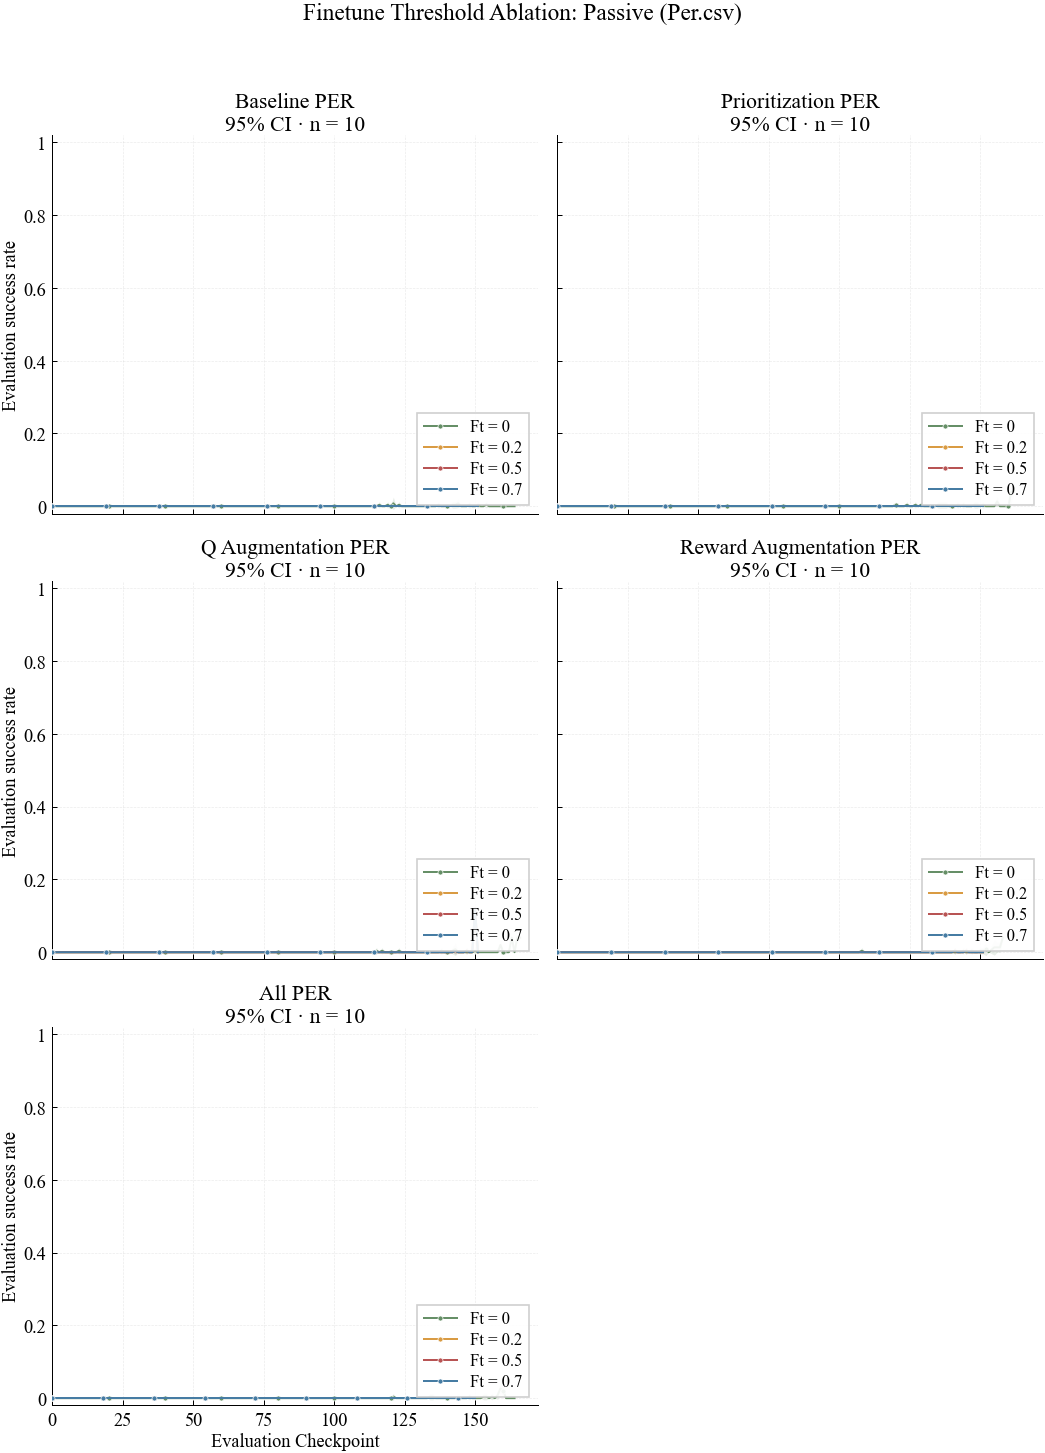

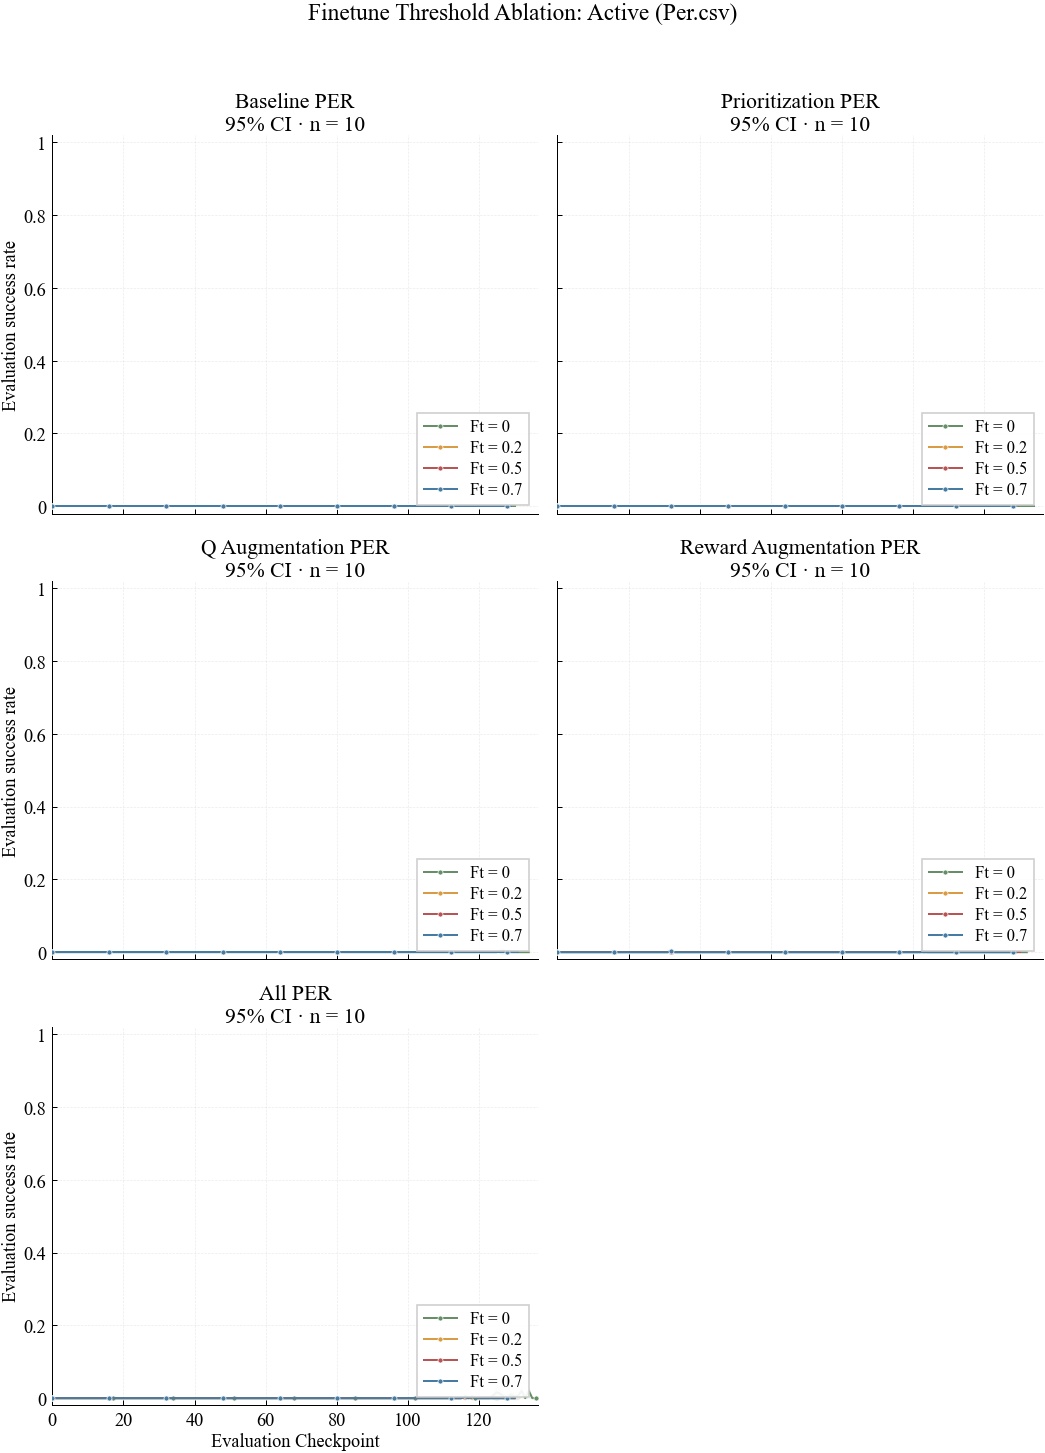

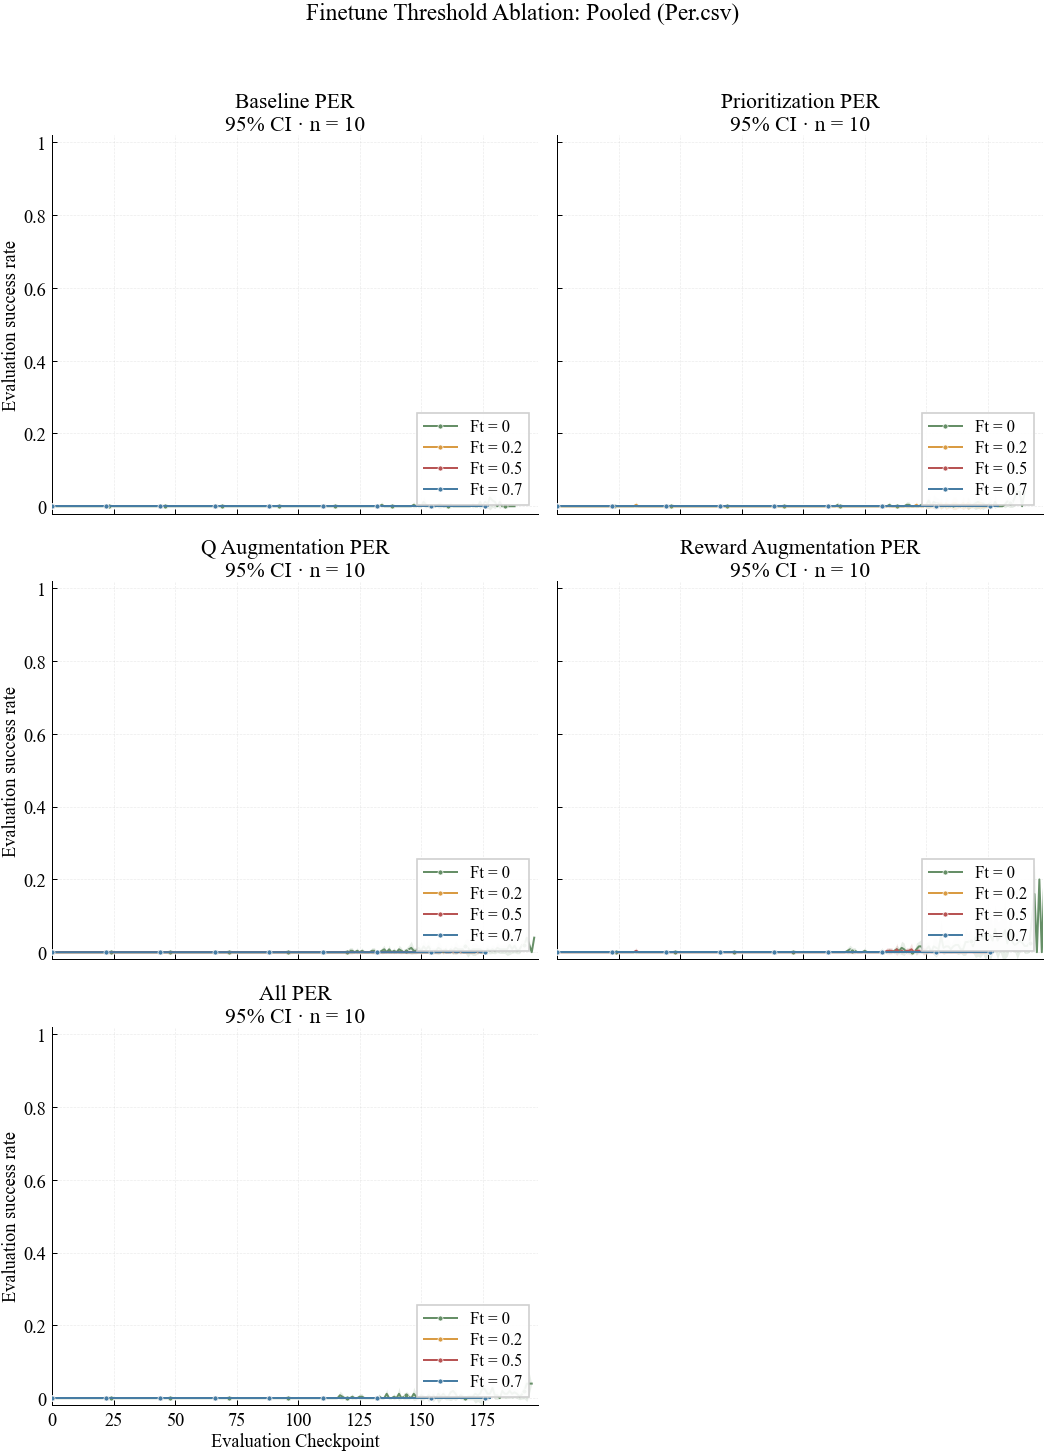

In [53]:
# --- Finetune-threshold ablation: one figure per task ---
# Subplots = neural conditions; lines = finetune_threshold (noise=0, β=1)
plot_finetune_threshold_ablation(agg, min_lines=1)


In [54]:
# --- Model-noise ablation: one figure per task ---
# Subplots = neural conditions; lines = model noise (β=1, ft=NOISE_BETA_ABLATION_FT)
plot_ablation_for_each_task(
    agg,
    ablation_kind="noise",
    min_lines=1,
    ft=0.4,
)


Skip Passive (noise): 0 conditions, 0 ablation levels
Skip Active (noise): 0 conditions, 0 ablation levels
Skip Pooled (noise): 0 conditions, 0 ablation levels


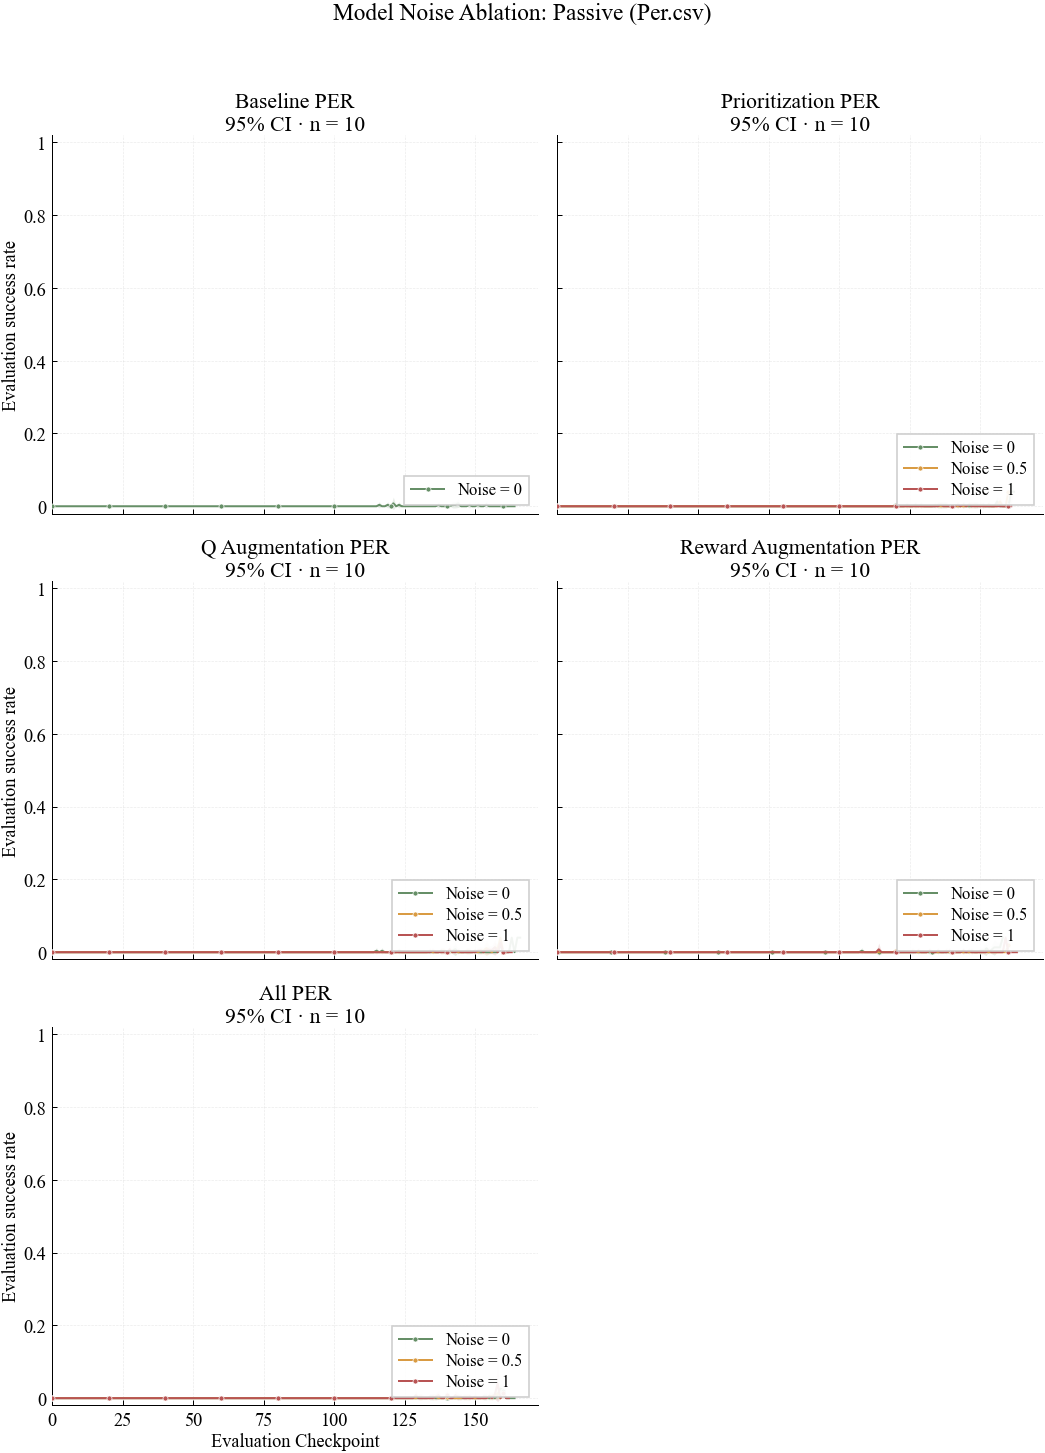

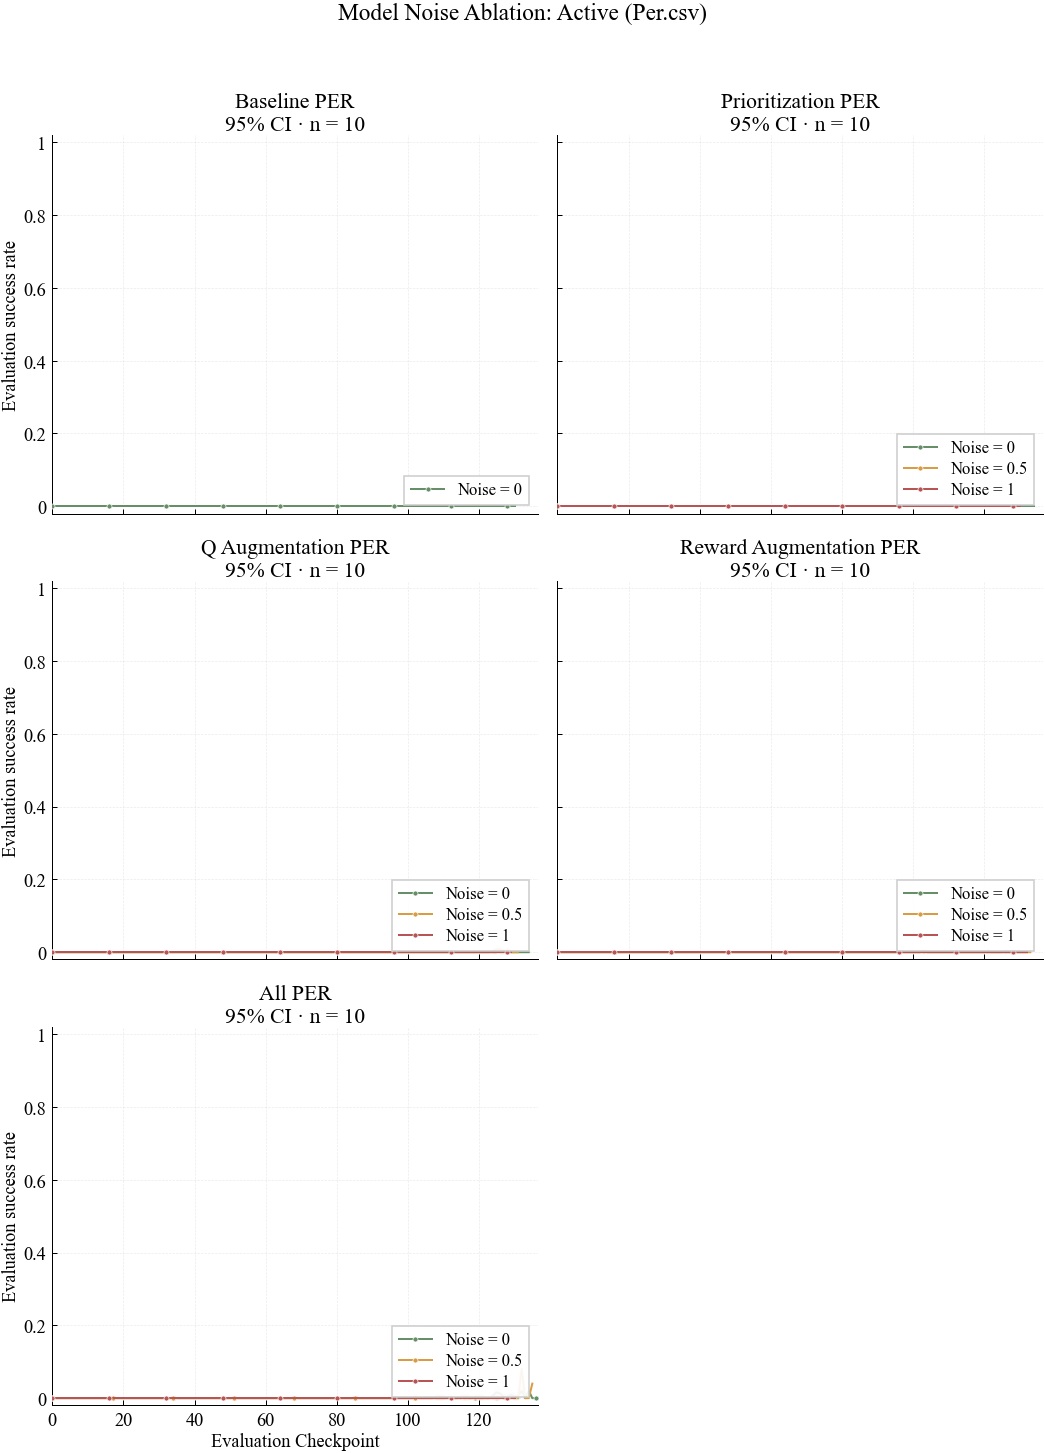

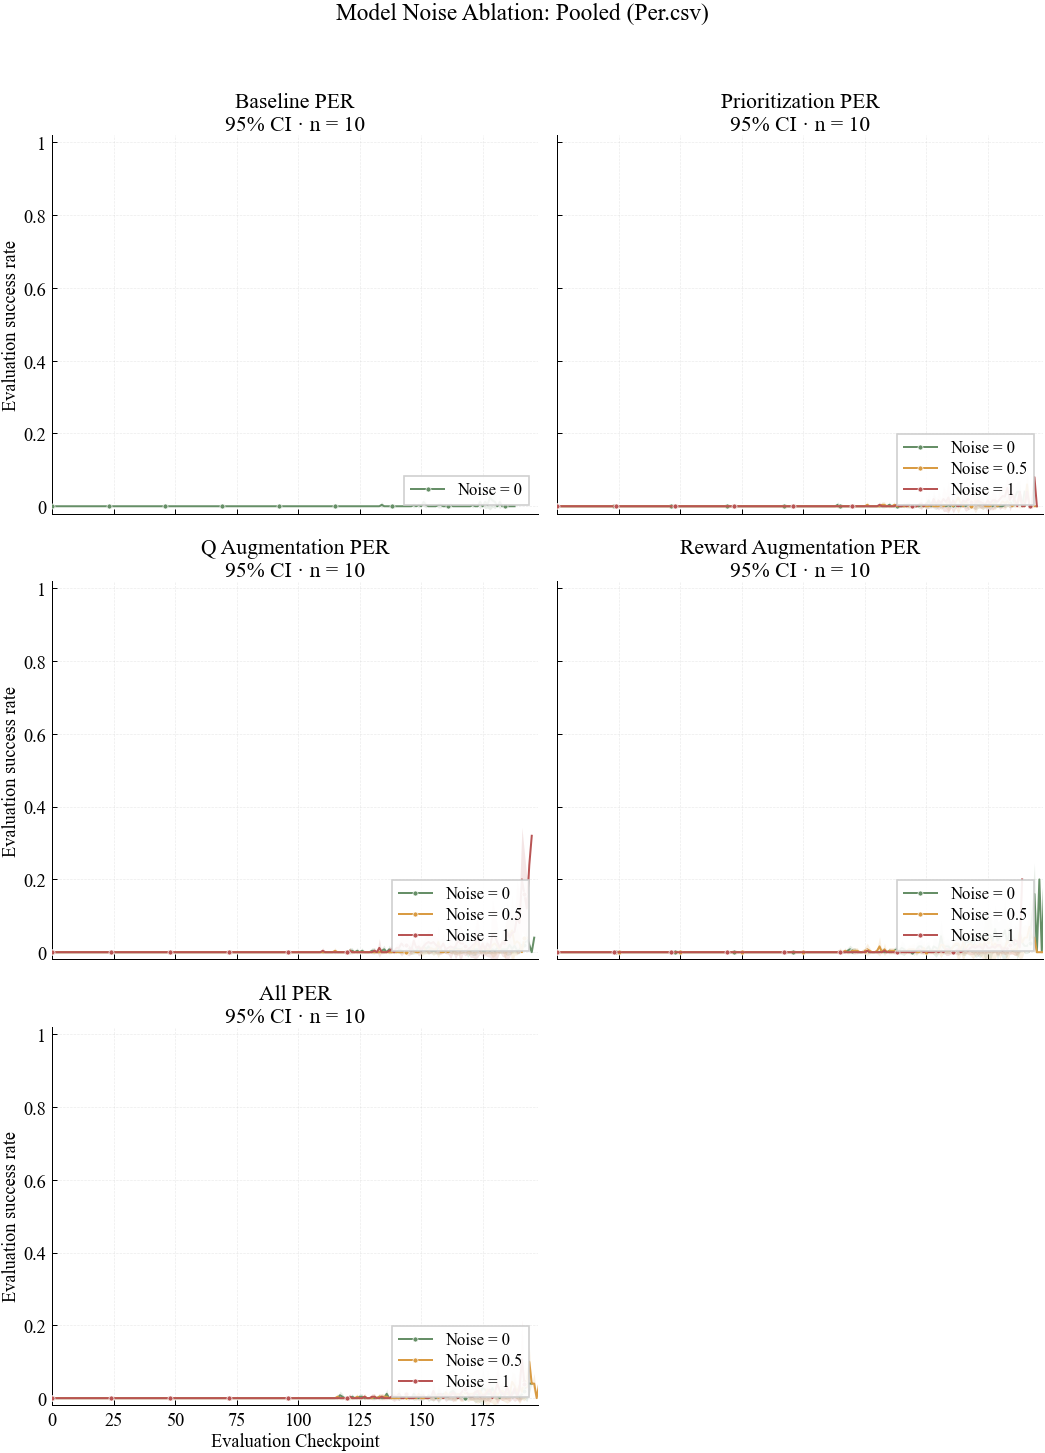

In [55]:
# --- Neural-β ablation: one figure per task ---
# Subplots = neural conditions; lines = β (noise=0, ft=NOISE_BETA_ABLATION_FT)
plot_ablation_for_each_task(
    agg,
    ablation_kind="noise",
    min_lines=1,
    ft=NOISE_BETA_ABLATION_FT,
)


In [56]:
# Summary tables per ablation (condition × level; fixed baselines as in config)
display_ablation_summaries(
    agg,
    ablation_col="ft",
    ablation_order=FT_ORDER,
    fixed={"noise": ABLATION_FT_BASELINE_NOISE, "beta": ABLATION_FT_BASELINE_BETA},
    label="Finetune threshold",
)

display_ablation_summaries(
    agg,
    ablation_col="noise",
    ablation_order=NOISE_ORDER,
    fixed={"beta": ABLATION_NOISE_BASELINE_BETA, "ft": ABLATION_NOISE_BASELINE_FT},
    label="Model noise",
)

display_ablation_summaries(
    agg,
    ablation_col="beta",
    ablation_order=BETA_ORDER,
    fixed={"noise": ABLATION_BETA_BASELINE_NOISE, "ft": ABLATION_BETA_BASELINE_FT},
    label="Neural β",
)


Finetune threshold — curve score per condition (fixed: noise = 0, beta = 1):


ft,0.0,0.2,0.5,0.7
condition,,,,
Baseline-PER,1.1,0.0,0.0,0.0
Prioritization-PER,1.1,0.0,0.0,0.0
Q-Augmentation-PER,0.0,1.1,1.1,1.1
Reward Augmentation-PER,1.1,0.0,0.0,0.0
All-PER,1.1,0.0,0.0,0.0


Peak Evaluation success rate:


ft,0.0,0.2,0.5,0.7
condition,,,,
Baseline-PER,0.008000,0.000,0.000,0.000
Prioritization-PER,0.040000,0.000,0.000,0.000
Q-Augmentation-PER,0.040000,0.120,0.120,0.120
Reward Augmentation-PER,0.040000,0.004,0.004,0.004
All-PER,0.026667,0.000,0.000,0.000


Terminal Evaluation success rate (last 1 checkpoints):


...

beta,0.5,1.0,5.0,10.0
condition,,,,
Baseline-PER,1.100000,0.0,1.100000,NaN
Prioritization-PER,1.100000,1.1,0.000000,NaN
Q-Augmentation-PER,0.000000,1.1,1.018182,NaN
Reward Augmentation-PER,0.000000,1.1,0.000000,NaN
All-PER,0.707143,1.1,0.000000,NaN


Peak Evaluation success rate:


beta,0.5,1.0,5.0,10.0
condition,,,,
Baseline-PER,0.040000,0.008000,0.040,NaN
Prioritization-PER,0.040000,0.040000,0.008,NaN
Q-Augmentation-PER,0.013333,0.040000,0.040,NaN
Reward Augmentation-PER,0.020000,0.040000,0.020,NaN
All-PER,0.020000,0.026667,0.008,NaN


Terminal Evaluation success rate (last 1 checkpoints):


beta,0.5,1.0,5.0,10.0
condition,,,,
Baseline-PER,0.00,0.00,0.0,NaN
Prioritization-PER,0.04,0.04,0.0,NaN
Q-Augmentation-PER,0.00,0.04,0.0,NaN
Reward Augmentation-PER,0.00,0.04,0.0,NaN
All-PER,0.00,0.00,0.0,NaN


In [57]:
# One figure per finetune_threshold: lines = conditions (alternative view)
def plot_conditions_at_each_ft(table: pd.DataFrame, *, tasks: list | None = None, start_idx: int | None = None, end_idx: int | None = None):
    task_list = tasks if tasks is not None else tasks_to_plot()
    for task in task_list:
        filters = {
            "task": task,
            "noise": ABLATION_FT_BASELINE_NOISE,
            "beta": ABLATION_FT_BASELINE_BETA,
        }
        sub = table.copy()
        for key, val in filters.items():
            if key in NUMERIC_ABLATION_COLS:
                sub = sub[np.isclose(sub[key], val)]
            else:
                sub = sub[sub[key] == val]

        ft_present = line_values_present(sub, "ft", FT_ORDER)
        conditions = subplot_values_present(sub, "condition", CONDITION_ORDER)
        if not ft_present or not conditions:
            print(f"Skip {task}: insufficient ft/condition data")
            continue

        publication_figure(
            table,
            title=study_headline(task, "Conditions by Finetune Threshold"),
            line_col="condition",
            line_values=conditions,
            subplot_col="ft",
            subplot_values=ft_present,
            filters=filters,
            filename=f"conditions_by_ft__{slugify(task)}.pdf",
            start_idx=start_idx,
            end_idx=end_idx,
        )


# Uncomment to plot the alternative layout:
# plot_conditions_at_each_ft(agg)


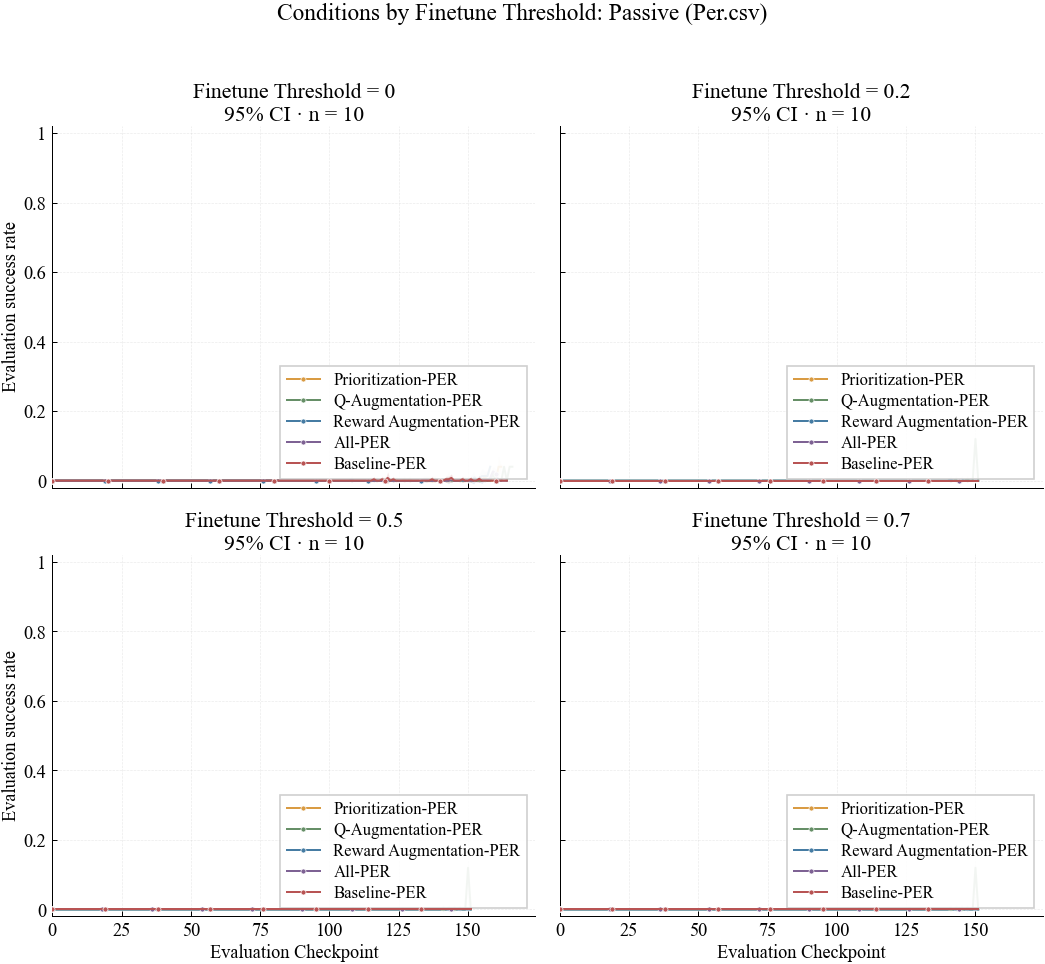

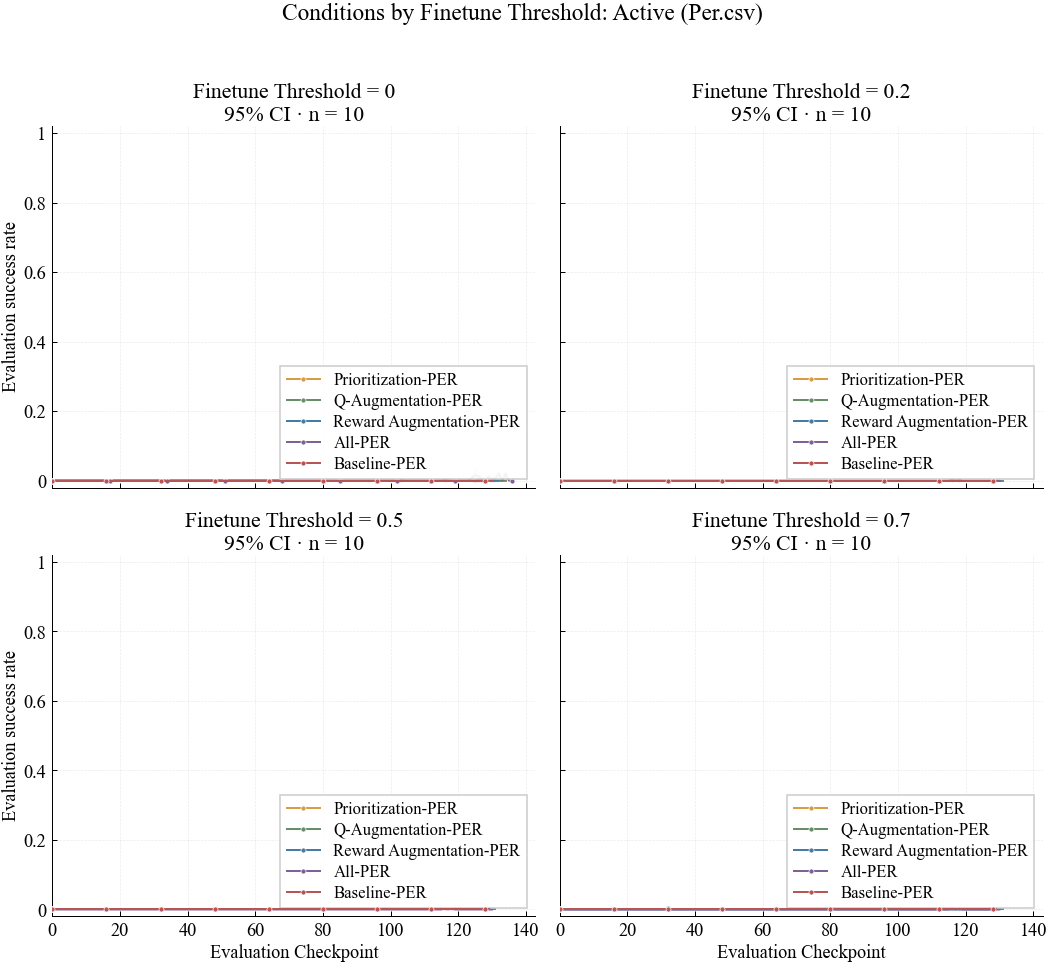

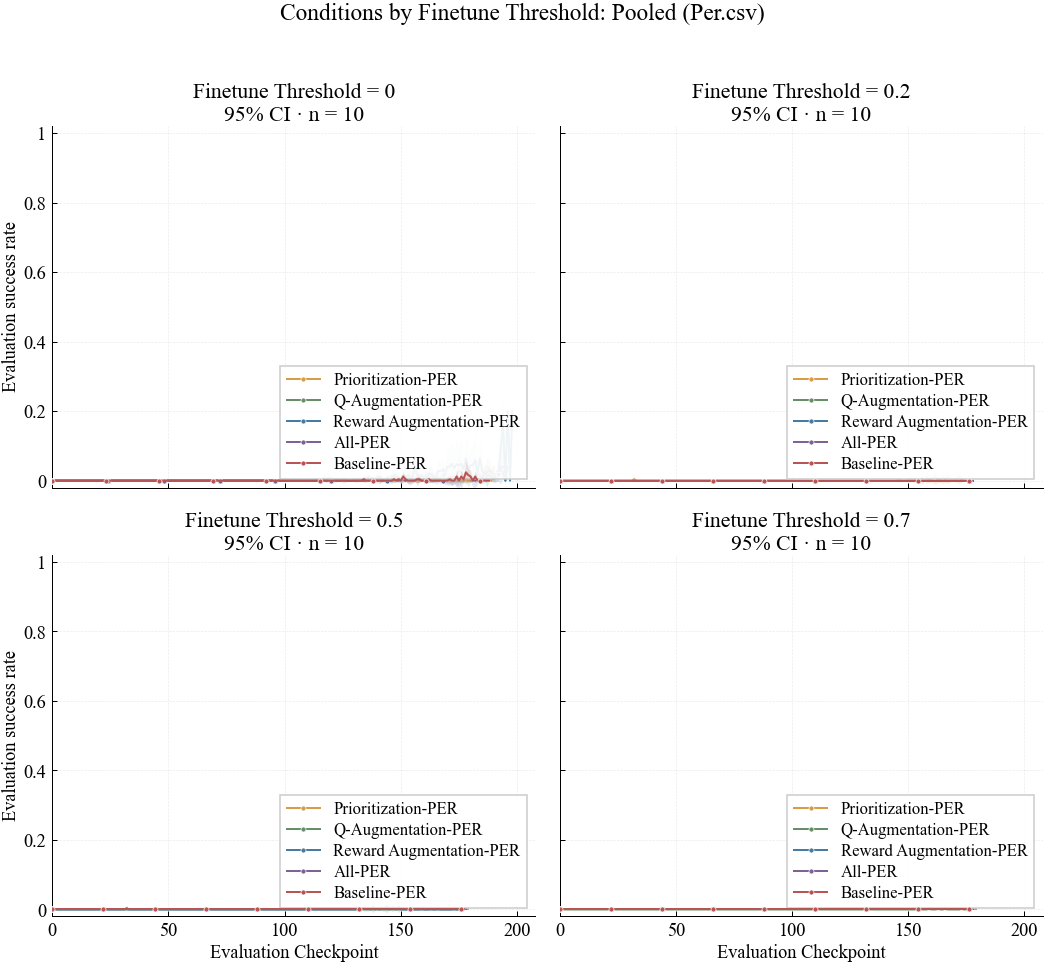

In [58]:
# Uncomment to plot the alternative layout:
plot_conditions_at_each_ft(agg, start_idx=0,end_idx=400)

Passive
Passive
Passive
Passive
Passive
Passive
Active
Active
Active
Active
Active
Active
Pooled
Pooled
Pooled
Pooled
Pooled
Pooled


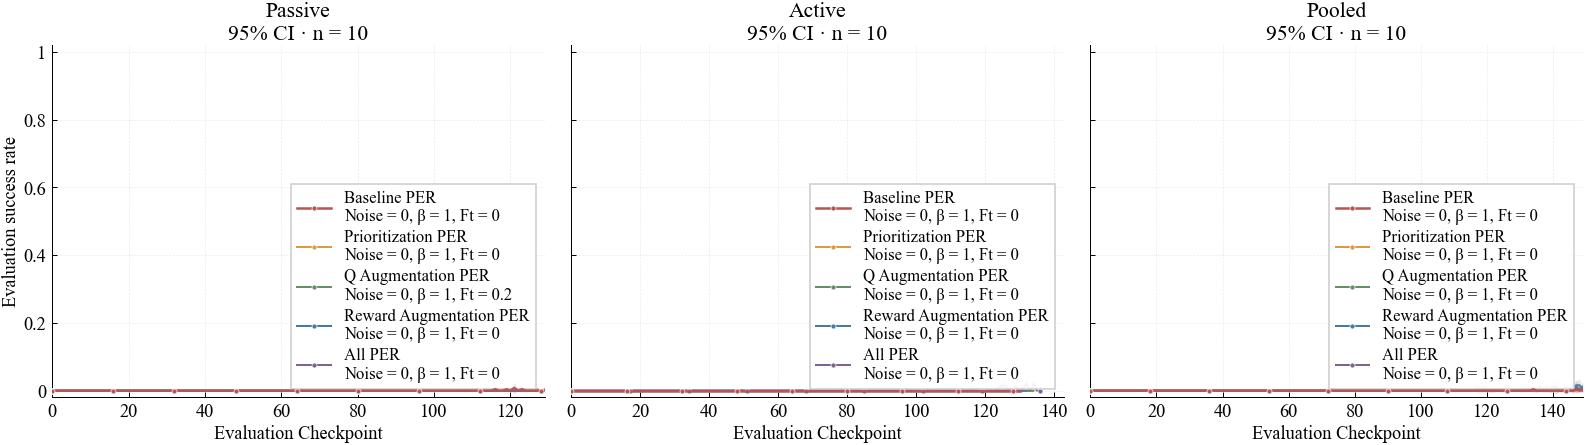

Appended 15 row(s) to /Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/best_results.csv


,saved_at,data_file,granularity,metric,error_band,task,condition,noise,beta,ft,...,curve_score,peak_reward,final_score,reward_score,trial_name,checkpoint_count,mean,std,sem,band_halfwidth
0,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Passive,Baseline-PER,0.0,1.0,0.0,...,1.1,0.008000,0.00,0.006400,Flappy__Passive__Baseline-PER__finetune__binar...,165,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Passive,Prioritization-PER,0.0,1.0,0.0,...,1.1,0.040000,0.04,0.040000,Flappy__Passive__Prioritization-PER__finetune_...,163,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Passive,Q-Augmentation-PER,0.0,1.0,0.2,...,1.1,0.120000,0.00,0.096000,Flappy__Passive__Q-Augmentation-PER__finetune_...,152,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Passive,Reward Augmentation-PER,0.0,1.0,0.0,...,1.1,0.040000,0.04,0.040000,Flappy__Passive__Reward Augmentation-PER__fine...,159,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Passive,All-PER,0.0,1.0,0.0,...,1.1,0.026667,0.00,0.021333,Flappy__Passive__All-PER__finetune__binary__no...,165,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Active,Baseline-PER,0.0,1.0,0.0,...,1.1,0.000000,0.00,0.000000,Flappy__Active__Baseline-PER__finetune__binary...,131,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Active,Prioritization-PER,0.0,1.0,0.0,...,1.1,0.000000,0.00,0.000000,Flappy__Active__Prioritization-PER__finetune__...,135,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Active,Q-Augmentation-PER,0.0,1.0,0.0,...,1.1,0.004000,0.00,0.003200,Flappy__Active__Q-Augmentation-PER__finetune__...,135,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,2026-07-15T15:28:53.985505+00:00,flappy_finetune_binary_PER.csv,PER.csv,results_success_rate,ci95,Active,Reward Augmentation-PER,0.0,1.0,0.0,...,1.1,0.004000,0.00,0.003200,Flappy__Active__Reward Augmentation-PER__finet...,133,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [59]:
# Optional: best (noise, β, ft) per task × condition summary figure
plot_conditions_best_per_task_condition(agg, filters=FT_BEST_FILTERS)
save_best_results_csv(agg, filters=FT_BEST_FILTERS)